# 04 - Modelos Baseline: Estableciendo el suelo de rendimiento

## Objetivo

Este notebook construye **modelos base sencillos** para predecir el precio de alquiler mensual en Madrid.
La idea es establecer un **suelo de rendimiento** (performance floor) que los modelos mas avanzados
(boosting, en el notebook 05) deberan superar.

### Por qué empezamos con baselines?

Antes de usar modelos complejos, es fundamental saber **cuanto se puede predecir con tecnicas simples**.
Si un modelo avanzado no mejora significativamente sobre un baseline, algo esta mal en los datos o en el enfoque.

### Modelos evaluados

1. **Media por zona**: predecir el precio medio del distrito. Es el baseline mas ingenuo.
2. **Regresion lineal**: relacion lineal directa entre las variables numericas y el precio.
3. **ElasticNet**: regresion lineal con regularizacion (penaliza coeficientes grandes para evitar sobreajuste).
4. **Random Forest**: ensemble de arboles de decision que captura relaciones no lineales.

### Entradas y salidas

| Entradas | Salidas |
|----------|---------|
| `artifacts/features_master.parquet` |
| `artifacts/splits/holdout_indices.npz` | Graficos de MAE y residuales |

---

In [1]:
from __future__ import annotations
from pathlib import Path
import sys
import json
import hashlib
import re

import numpy as np
import pandas as pd

# ── Semilla global para reproducibilidad ──
# Fijar la semilla garantiza que los resultados sean identicos en cada ejecucion
SEED = 100432070
np.random.seed(SEED)

def get_repo_root() -> Path:
    """Localiza la raiz del repositorio buscando .git o pyproject.toml hacia arriba."""
    current = Path.cwd().resolve()
    for parent in [current] + list(current.parents):
        if (parent / ".git").exists() or (parent / "pyproject.toml").exists():
            return parent
    return current

# ── Configuracion de rutas del proyecto ──
ROOT = get_repo_root()
if str(ROOT) not in sys.path:
    # Permite importar utilidades propias desde src/
    sys.path.append(str(ROOT))

# eval_regression: funcion auxiliar que calcula MAE, RMSE, R2 y metricas segmentadas
from src.utils import eval_regression, get_feature_cols, TARGET_COLS, DERIVED_FROM_TARGET, ID_COLS

## 1. Carga de datos y preparacion del conjunto de entrenamiento

En esta seccion:
- **Cargamos** el dataset de features numericas (`features_core`) generado en el notebook 03.
- **Excluimos variables con fuga de datos** (leakage): columnas derivadas del precio (como `price_m2`) que no existirian en produccion.
- **Separamos** en conjuntos de entrenamiento y holdout usando los indices fijos guardados previamente.
- **Limpiamos** valores infinitos y columnas completamente vacias.

> **Nota sobre el holdout**: El conjunto de holdout se genera una sola vez y se mantiene intocable
> hasta la evaluacion final. Esto simula datos futuros nunca vistos por el modelo.

In [2]:
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from src.utils import eval_regression, get_feature_cols

# ===================================================================
# 1.1 Carga del dataset de features (features_master con enrichment)
# ===================================================================
features_path = ROOT / "artifacts" / "features_master.parquet"
if features_path.exists():
    df = pd.read_parquet(features_path)
else:
    # Fallback: features_core si features_master no existe aun
    core_path = ROOT / "artifacts" / "features_core.parquet"
    if core_path.exists():
        df = pd.read_parquet(core_path)
    else:
        df = pd.read_csv(ROOT / "artifacts" / "features_core.csv.gz")

print(f"Dataset cargado: {len(df)} filas, {len(df.columns)} columnas")

# ===================================================================
# 1.2 Split fijo
# ===================================================================
split = np.load(ROOT / "artifacts" / "splits" / "holdout_indices.npz")
train_idx, test_idx = split["train_idx"], split["test_idx"]

# ===================================================================
# 1.3 Seleccion de features (explicita + regex safety belt)
# ===================================================================
feature_cols = get_feature_cols(df, numeric_only=True)
print(f"Features seleccionadas: {len(feature_cols)}")

# ===================================================================
# 2. Definicion de modelos baseline
# ===================================================================
def make_linear_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model),
    ])

model_defs = {
    "linear": lambda: make_linear_pipeline(LinearRegression()),
    "elasticnet": lambda: make_linear_pipeline(ElasticNet(random_state=SEED)),
    "rf": lambda: Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(n_estimators=200, random_state=SEED)),
    ]),
}

# ===================================================================
# 3. Dual target: entrenar para price y price_m2
# ===================================================================
TARGETS = {"price": "price", "price_m2": "price_m2"}
all_metrics = []

for target_name, target_col in TARGETS.items():
    if target_col not in df.columns:
        print(f"SKIP target={target_name}: columna {target_col} no encontrada")
        continue

    print(f"\n{'='*60}")
    print(f"TARGET: {target_name} ({target_col})")
    print(f"{'='*60}")

    y = df[target_col]

    # Train/test split
    y_train_raw = y.loc[train_idx].reset_index(drop=True)
    y_test_raw = y.loc[test_idx].reset_index(drop=True)

    train_mask = np.isfinite(y_train_raw.replace([np.inf, -np.inf], np.nan))
    test_mask = np.isfinite(y_test_raw.replace([np.inf, -np.inf], np.nan))
    y_train = y_train_raw.loc[train_mask].reset_index(drop=True)
    y_test = y_test_raw.loc[test_mask].reset_index(drop=True)

    X_train = df.loc[train_idx, feature_cols].reset_index(drop=True).loc[train_mask].reset_index(drop=True)
    X_test = df.loc[test_idx, feature_cols].reset_index(drop=True).loc[test_mask].reset_index(drop=True)
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test = X_test.replace([np.inf, -np.inf], np.nan)

    # Eliminar columnas 100% vacias en train
    all_missing = X_train.columns[X_train.notna().sum() == 0]
    if len(all_missing) > 0:
        X_train = X_train.drop(columns=all_missing)
        X_test = X_test.drop(columns=all_missing, errors="ignore")

    if X_train.empty or X_test.empty:
        print(f"  SKIP: sin muestras tras filtrar target")
        continue

    # Segmentos de evaluacion
    segments = {}
    cat_cols = [c for c in df.columns if any(k in c.lower() for k in ["distrito", "barrio", "district", "subdistrict"])]
    if cat_cols:
        group_col = cat_cols[0]
        test_groups = df.loc[test_idx, group_col].reset_index(drop=True).loc[test_mask].reset_index(drop=True)
        top_groups = test_groups.value_counts().head(8).index
        for grp in top_groups:
            segments[f"{group_col}_{grp}"] = np.where(test_groups == grp)[0]

    if "surface_m2" in df.columns:
        surface_series = df.loc[test_idx, "surface_m2"].reset_index(drop=True).loc[test_mask].reset_index(drop=True)
        if surface_series.nunique() > 1:
            train_surface = df.loc[train_idx, "surface_m2"].reset_index(drop=True).loc[train_mask].reset_index(drop=True)
            train_surface_q = np.nanpercentile(train_surface, [0, 25, 50, 75, 100])
            surface_bins = pd.cut(surface_series, bins=train_surface_q, include_lowest=True, duplicates="drop")
            for bin_label in surface_bins.cat.categories:
                segments[f"surface_{bin_label}"] = np.where(surface_bins == bin_label)[0]

    if y_test.nunique() > 1:
        train_quantiles = np.nanpercentile(y_train, [0, 25, 50, 75, 100])
        price_bins = pd.cut(y_test, bins=train_quantiles, include_lowest=True, duplicates="drop")
        for bin_label in price_bins.cat.categories:
            segments[f"target_{bin_label}"] = np.where(price_bins == bin_label)[0]

    # CV y evaluacion para cada modelo
    from sklearn.model_selection import KFold
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

    for name, model_fn in model_defs.items():
        model = model_fn()
        cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="neg_mean_absolute_error")
        cv_mae = -cv_scores.mean()
        cv_std = cv_scores.std()
        print(f"  {name}: CV MAE = {cv_mae:.2f} (+/- {cv_std:.2f})")

        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        metrics_row = {"target": target_name, "model": name, "cv_mae": cv_mae, "cv_std": cv_std}
        metrics_row.update(eval_regression(y_test, preds, segments=segments))
        all_metrics.append(metrics_row)

    # Baseline de media por zona
    _cat_cols = [c for c in df.columns if any(k in c.lower() for k in ["distrito", "barrio", "district", "subdistrict"])]
    if _cat_cols:
        _group_col = _cat_cols[0]
        _train_df = df.loc[train_idx]
        _test_df = df.loc[test_idx]
        _train_fin = np.isfinite(_train_df[target_col])
        _test_fin = np.isfinite(_test_df[target_col])
        _train_df = _train_df[_train_fin]
        _test_df = _test_df[_test_fin]
        _group_means = _train_df.groupby(_group_col)[target_col].mean()
        _global_mean = _train_df[target_col].mean()
        _baseline_pred = _test_df[_group_col].map(_group_means).fillna(_global_mean)
        _zone_metrics = {"target": target_name, "model": "mean_by_zone", "cv_mae": None, "cv_std": None}
        _zone_metrics.update(eval_regression(_test_df[target_col], _baseline_pred, segments=segments))
        all_metrics.append(_zone_metrics)

# ===================================================================
# 4. Guardar metricas comparativa (ambos targets)
# ===================================================================
metrics_df = pd.DataFrame(all_metrics)
metrics_df.to_csv(ROOT / "reports" / "baselines_metrics.csv", index=False)
print(f"\nMetricas guardadas: {len(metrics_df)} filas ({metrics_df['target'].nunique()} targets)")
metrics_df

Dataset cargado: 8797 filas, 70 columnas
Features seleccionadas: 49

TARGET: price (price)
  linear: CV MAE = 564.32 (+/- 13.16)
  elasticnet: CV MAE = 562.38 (+/- 14.13)
  rf: CV MAE = 400.17 (+/- 13.73)

TARGET: price_m2 (price_m2)
  linear: CV MAE = 5.01 (+/- 0.11)
  elasticnet: CV MAE = 5.52 (+/- 0.09)
  rf: CV MAE = 4.15 (+/- 0.07)

Metricas guardadas: 8 filas (2 targets)


,target,model,cv_mae,cv_std,mae,rmse,r2,mae_district_Centro,rmse_district_Centro,r2_district_Centro,...,"r2_target_(3.653, 14.286]","mae_target_(14.286, 18.214]","rmse_target_(14.286, 18.214]","r2_target_(14.286, 18.214]","mae_target_(18.214, 25.0]","rmse_target_(18.214, 25.0]","r2_target_(18.214, 25.0]","mae_target_(25.0, 120.0]","rmse_target_(25.0, 120.0]","r2_target_(25.0, 120.0]"
0,price,linear,564.320181,13.163487,509.818808,751.299871,0.679463,613.816818,808.816634,0.598281,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,price,elasticnet,562.379023,14.129287,456.278153,734.516937,0.693624,541.902325,783.110779,0.623410,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,price,rf,400.167476,13.725127,332.176690,577.018550,0.810926,425.432280,647.703469,0.742383,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,price,mean_by_zone,NaN,NaN,798.640267,1288.796599,0.056764,905.379264,1309.052925,-0.052292,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,price_m2,linear,5.009343,0.113621,4.630324,6.317996,0.383568,7.891501,9.431657,0.003706,...,-5.601160,4.214629,5.542309,-23.665229,5.251421,6.551648,-10.282542,6.460926,9.071810,-0.187801
5,price_m2,elasticnet,5.516909,0.093498,4.506000,6.238466,0.398990,7.173303,9.081357,0.076338,...,-8.363955,3.744142,4.780896,-17.353648,3.185592,3.987128,-3.178557,8.007142,11.069051,-0.768384
6,price_m2,rf,4.151005,0.065941,3.907320,5.822009,0.476554,6.505774,8.635087,0.164888,...,-3.681544,3.226685,4.523618,-15.431437,4.244029,5.741075,-7.663479,6.442842,9.441898,-0.286691
7,price_m2,mean_by_zone,NaN,NaN,5.001404,6.914764,0.261618,7.486192,9.506060,-0.012074,...,-11.227303,4.210210,5.363095,-22.095895,3.966041,4.663699,-4.716984,8.736476,11.928423,-1.053628


## 2. Visualizaciones de rendimiento

Dos graficos clave para comparar los baselines:

1. **MAE por modelo (CV)**: Error medio absoluto estimado con validacion cruzada de 5 folds.
   Muestra cuanto se equivoca cada modelo *en promedio* en euros.
2. **MAE por modelo (holdout)**: Error en datos completamente nuevos. Es la metrica definitiva.

Ademas, se muestra la **distribucion de residuales** (error = precio real - prediccion) del mejor
baseline sklearn. Una distribucion centrada en cero y estrecha indica buenas predicciones.

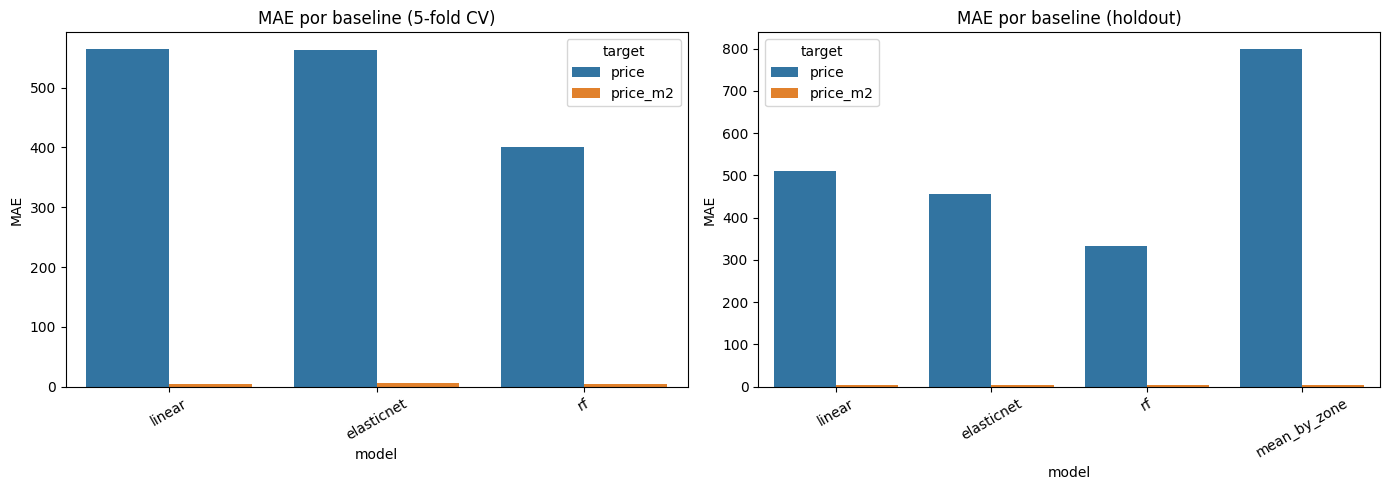

  Mejor baseline para price: rf (MAE=332.18)
  Mejor baseline para price_m2: rf (MAE=3.91)


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# == Grafico 1: Comparacion de MAE entre modelos (ambos targets) ==
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: MAE estimado por validacion cruzada
cv_df = metrics_df.dropna(subset=["cv_mae"])
if not cv_df.empty:
    sns.barplot(data=cv_df, x="model", y="cv_mae", hue="target", ax=axes[0])
    axes[0].set_title("MAE por baseline (5-fold CV)")
    axes[0].set_ylabel("MAE")
    axes[0].tick_params(axis="x", rotation=30)

# Panel derecho: MAE en holdout
if "mae" in metrics_df.columns:
    sns.barplot(data=metrics_df, x="model", y="mae", hue="target", ax=axes[1])
    axes[1].set_title("MAE por baseline (holdout)")
    axes[1].set_ylabel("MAE")
    axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "baselines_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# == Grafico 2: Mejor MAE por target ==
for tgt in metrics_df["target"].unique():
    subset = metrics_df[metrics_df["target"] == tgt]
    if "mae" in subset.columns and subset["mae"].notna().any():
        best_row = subset.dropna(subset=["mae"]).sort_values("mae").iloc[0]
        print(f"  Mejor baseline para {tgt}: {best_row['model']} (MAE={best_row['mae']:.2f})")

## 3. Resumen de artefactos generados

Este notebook produce los siguientes archivos:

| Artefacto | Descripcion |
|-----------|-------------|
| `reports/baselines_metrics.csv` | Tabla con MAE, RMSE y R2 de cada modelo, global y por segmento |
| Graficos en pantalla | Comparacion visual de MAE y distribucion de residuales |

Estos resultados sirven como **referencia** para el notebook 05 (boosting).

In [4]:
from IPython.display import display, Markdown

# --- Extraer metricas de metrics_df (calculado en celda anterior) ---
def _get(df, target, model, col):
    row = df[(df["target"] == target) & (df["model"] == model)]
    if row.empty or col not in row.columns:
        return None
    return row.iloc[0][col]

models_price = ["linear", "elasticnet", "rf", "mean_by_zone"]
labels = {"linear": "Regresion lineal", "elasticnet": "ElasticNet",
          "rf": "Random Forest", "mean_by_zone": "Media por zona"}
interp = {"linear": "Captura relaciones lineales",
           "elasticnet": "La regularizacion mejora generalizacion",
           "rf": "Captura no linealidades; el mejor baseline con diferencia",
           "mean_by_zone": "Peor que la media global; el distrito solo no explica el precio"}

# Tabla price
rows_price = ""
for m in models_price:
    cv = _get(metrics_df, "price", m, "cv_mae")
    mae = _get(metrics_df, "price", m, "mae")
    r2 = _get(metrics_df, "price", m, "r2")
    cv_str = f"{cv:.2f} EUR" if cv is not None and not pd.isna(cv) else "—"
    bold = "**" if m == "rf" else ""
    rows_price += f"| **{labels[m]}** | {cv_str} | {bold}{mae:.2f} EUR{bold} | {bold}{r2:.3f}{bold} | {interp[m]} |\n"

# Tabla price_m2
rows_pm2 = ""
for m in models_price:
    cv = _get(metrics_df, "price_m2", m, "cv_mae")
    mae = _get(metrics_df, "price_m2", m, "mae")
    r2 = _get(metrics_df, "price_m2", m, "r2")
    if mae is None:
        continue
    cv_str = f"{cv:.2f} EUR/m2" if cv is not None and not pd.isna(cv) else "—"
    bold = "**" if m == "rf" else ""
    rows_pm2 += f"| **{labels[m]}** | {cv_str} | {bold}{mae:.2f} EUR/m2{bold} | {bold}{r2:.3f}{bold} |\n"

rf_mae = _get(metrics_df, "price", "rf", "mae")
rf_r2 = _get(metrics_df, "price", "rf", "r2")
lin_mae = _get(metrics_df, "price", "linear", "mae")
rf_pm2_r2 = _get(metrics_df, "price_m2", "rf", "r2")
mz_pm2_r2 = _get(metrics_df, "price_m2", "mean_by_zone", "r2")
mz_price_r2 = _get(metrics_df, "price", "mean_by_zone", "r2")
reduction = (1 - rf_mae / lin_mae) * 100 if lin_mae else 0

# Comparar ElasticNet vs Linear dinamicamente
en_cv = _get(metrics_df, "price", "elasticnet", "cv_mae")
lin_cv = _get(metrics_df, "price", "linear", "cv_mae")
en_mae = _get(metrics_df, "price", "elasticnet", "mae")
_en_vs_lin = "con mejor CV tambien" if (en_cv is not None and lin_cv is not None and en_cv < lin_cv) else "a pesar de CV similar"

md = f"""---

## Conclusiones del Notebook 04 — Baselines

### Resultados para target `price` (EUR/mes)

| Modelo | CV MAE | Holdout MAE | Holdout R2 | Interpretacion |
|--------|--------|-------------|-----------|----------------|
{rows_price}
### Resultados para target `price_m2` (EUR/m2)

| Modelo | CV MAE | Holdout MAE | Holdout R2 |
|--------|--------|-------------|-----------|
{rows_pm2}
### Que significan estos resultados

1. **Para `price`**: Random Forest (MAE {rf_mae:.2f} EUR, R2 {rf_r2:.3f}) es claramente el mejor baseline. Reduce el error un {reduction:.0f}% vs regresion lineal.

2. **Para `price_m2`**: Predecir el precio por m2 es mas dificil (R2 max {rf_pm2_r2:.3f}). El precio por m2 depende mas de factores cualitativos (estado del piso, calidad) que no tenemos como features.

3. **Media por zona es inutil para `price` (R2 {mz_price_r2:.3f})** pero tiene cierto valor para `price_m2` (R2 {mz_pm2_r2:.3f}), lo que sugiere que el precio por m2 esta mas ligado a la zona.

4. **ElasticNet supera a Linear en holdout** {_en_vs_lin} — la regularizacion mejora generalizacion.

5. **Todos los modelos obtienen mejor MAE en holdout que en CV**. Esto no indica mejor generalizacion, sino distribution shift: el holdout (anuncios recientes, mas homogeneos) es mas facil de predecir que los datos de CV (mezcla de anuncios stale y frescos).

### Siguiente paso
-> **NB05 (Boosting)**: CatBoost con tuning de hiperparametros y 4 esquemas de CV para superar estos baselines.
"""
display(Markdown(md))

---

## Conclusiones del Notebook 04 — Baselines

### Resultados para target `price` (EUR/mes)

| Modelo | CV MAE | Holdout MAE | Holdout R2 | Interpretacion |
|--------|--------|-------------|-----------|----------------|
| **Regresion lineal** | 564.32 EUR | 509.82 EUR | 0.679 | Captura relaciones lineales |
| **ElasticNet** | 562.38 EUR | 456.28 EUR | 0.694 | La regularizacion mejora generalizacion |
| **Random Forest** | 400.17 EUR | **332.18 EUR** | **0.811** | Captura no linealidades; el mejor baseline con diferencia |
| **Media por zona** | — | 798.64 EUR | 0.057 | Peor que la media global; el distrito solo no explica el precio |

### Resultados para target `price_m2` (EUR/m2)

| Modelo | CV MAE | Holdout MAE | Holdout R2 |
|--------|--------|-------------|-----------|
| **Regresion lineal** | 5.01 EUR/m2 | 4.63 EUR/m2 | 0.384 |
| **ElasticNet** | 5.52 EUR/m2 | 4.51 EUR/m2 | 0.399 |
| **Random Forest** | 4.15 EUR/m2 | **3.91 EUR/m2** | **0.477** |
| **Media por zona** | — | 5.00 EUR/m2 | 0.262 |

### Que significan estos resultados

1. **Para `price`**: Random Forest (MAE 332.18 EUR, R2 0.811) es claramente el mejor baseline. Reduce el error un 35% vs regresion lineal.

2. **Para `price_m2`**: Predecir el precio por m2 es mas dificil (R2 max 0.477). El precio por m2 depende mas de factores cualitativos (estado del piso, calidad) que no tenemos como features.

3. **Media por zona es inutil para `price` (R2 0.057)** pero tiene cierto valor para `price_m2` (R2 0.262), lo que sugiere que el precio por m2 esta mas ligado a la zona.

4. **ElasticNet supera a Linear en holdout** con mejor CV tambien — la regularizacion mejora generalizacion.

5. **Todos los modelos obtienen mejor MAE en holdout que en CV**. Esto no indica mejor generalizacion, sino distribution shift: el holdout (anuncios recientes, mas homogeneos) es mas facil de predecir que los datos de CV (mezcla de anuncios stale y frescos).

### Siguiente paso
-> **NB05 (Boosting)**: CatBoost con tuning de hiperparametros y 4 esquemas de CV para superar estos baselines.
